在 PyTorch 中，张量（Tensor）是核心数据结构，用于表示数据。

每个张量都有三个重要的属性：
- dtype（数据类型）
- device（设备）
- layout（布局）。

这些属性共同决定了张量的存储方式和操作行为。

### 数据类型（dtype）
dtype 表示张量中存储的数据类型。PyTorch 支持多种数据类型，包括浮点数、整数和布尔值等。常见的数据类型有：
- torch.float32 或 torch.float：32位浮点数
- torch.float64 或 torch.double：64位浮点数
- torch.float16 或 torch.half：16位浮点数
- torch.int32 或 torch.int：32位整数
- torch.int64 或 torch.long：64位整数
- torch.uint8：8位无符号整数
- torch.bool：布尔值

In [2]:
import torch

# 创建一个张量并指定数据类型
x = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)
print(x.dtype)  # 输出: torch.float32

# 转换数据类型
x = x.to(torch.int64)
print(x.dtype)  # 输出: torch.int64

torch.float32
torch.int64


### 2. 设备（device）

device 表示张量存储的设备，可以是 CPU 或 GPU。PyTorch 支持在多个设备上进行计算，这使得利用 GPU 加速计算变得非常容易。

In [3]:
# 检查是否有可用的 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # 输出: cuda 或 cpu

# 创建一个张量并指定设备
x = torch.tensor([1.0, 2.0, 3.0], device=device)
print(x.device)  # 输出: cuda:0 或 cpu

# 将张量移动到另一个设备
if torch.cuda.is_available():
    x = x.to("cuda:0")
    print(x.device)  # 输出: cuda:0

cpu
cpu


### 布局（layout）

layout 表示张量的存储布局。

PyTorch 支持多种布局，包括
- 密集张量（torch.strided）
- 稀疏张量（torch.sparse_coo）
- 量化张量（torch.quint8 等）

默认情况下，张量是密集的。

In [4]:
# 创建一个密集张量
x = torch.tensor([[1, 2], [3, 4]])
print(x.layout)  # 输出: torch.strided

# 创建一个稀疏张量
indices = torch.tensor([[0, 1, 1], [2, 0, 2]])
values = torch.tensor([3, 4, 5], dtype=torch.float32)
shape = (2, 3)

x_sparse = torch.sparse_coo_tensor(indices, values, shape)
print(x_sparse.layout)  # 输出: torch.sparse_coo

torch.strided
torch.sparse_coo


# torch.new_*

在 PyTorch 中，torch.new_* 方法用于创建与现有张量具有相同设备（device）和数据类型（dtype），但大小（size）不同的新张量。
- 这些方法非常有用，尤其是在需要创建与现有张量具有相同属性但不同形状的张量时。

常见的 torch.new_* 方法
以下是一些常用的 torch.new_* 方法：
- torch.new_zeros：创建一个与现有张量具有相同设备和数据类型，但大小不同的全零张量。
- torch.new_ones：创建一个与现有张量具有相同设备和数据类型，但大小不同的全一张量。
- torch.new_empty：创建一个与现有张量具有相同设备和数据类型，但大小不同的未初始化张量。
- torch.new_full：创建一个与现有张量具有相同设备和数据类型，但大小不同且填充指定值的张量。
- torch.new_tensor：创建一个与现有张量具有相同设备和数据类型，但大小不同且包含指定数据的张量。

In [8]:
import torch

# 创建一个现有的张量
x = torch.tensor([1, 2, 3], dtype=torch.float32, device='cpu')
print(x)

# 创建一个全零张量，大小为 (2, 3)
y = x.new_zeros(2, 3)
print(y)

tensor([1., 2., 3.])
tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [9]:
# 创建一个全一张量，大小为 (2, 3)
y = x.new_ones(2, 3)
print(y)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [10]:
# 创建一个填充值为 5 的张量，大小为 (2, 3)
y = x.new_full((2, 3), 5)
print(y)

tensor([[5., 5., 5.],
        [5., 5., 5.]])


In [11]:
# 创建一个包含指定数据的张量
data = [[1, 2], [3, 4]]
y = x.new_tensor(data)
print(y)

tensor([[1., 2.],
        [3., 4.]])


### torch.from_numpy

torch.from_numpy 是 PyTorch 中的一个非常有用的方法，用于将 NumPy 数组转换为 PyTorch 张量（Tensor）。
- 这个方法不仅保留了 NumPy 数组的数据，还保留了其形状和数据类型，
- 并且转换后的张量与原始 NumPy 数组<font color='red'>共享内存。<font>
    
#### torch.from_numpy 的主要作用是：
- 数据共享：转换后的 PyTorch 张量与原始 NumPy 数组共享内存，这意味着对一个对象的修改会反映在另一个对象上。
- 无缝转换：允许你无缝地在 NumPy 和 PyTorch 之间转换数据，方便在不同框架之间进行数据处理和计算。


In [12]:
import numpy as np
import torch

# 创建一个 NumPy 数组
np_array = np.array([[1, 2], [3, 4]])

# 将 NumPy 数组转换为 PyTorch 张量
torch_tensor = torch.from_numpy(np_array)

print(torch_tensor)
# 输出:
# tensor([[1, 2],
#         [3, 4]])

tensor([[1, 2],
        [3, 4]])


In [13]:
# 修改 NumPy 数组
np_array[0, 0] = 10

print(torch_tensor)
# 输出:
# tensor([[10,  2],
#         [ 3,  4]])

tensor([[10,  2],
        [ 3,  4]])


In [14]:
# 创建一个 NumPy 数组，数据类型为 float32
np_array = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)

# 将 NumPy 数组转换为 PyTorch 张量
torch_tensor = torch.from_numpy(np_array)

print(torch_tensor.dtype)
# 输出: torch.float32

torch.float32


#### torch.from_numpy 创建的张量默认在 CPU 上。
- 如果需要将张量移动到 GPU，可以使用 .to(device) 方法。

In [16]:
# 将张量移动到 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_tensor = torch_tensor.to(device)
print(torch_tensor.device)

# 改变张量的数据类型
torch_tensor = torch_tensor.to(torch.float64)

print(torch_tensor)
# 输出: tensor([[10.,  2.],
#               [ 3.,  4.]], device='cuda:0', dtype=torch.float64)

cpu
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


## 创建特定Tensor


In [17]:
from IPython.display import Image

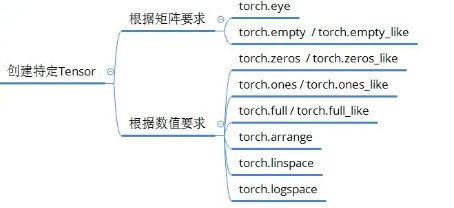

In [18]:
Image(filename='./Image/define_tensor.png',width=600)

### torch.eye 是 PyTorch 中的一个函数，用于创建一个单位矩阵（Identity Matrix）。
- 单位矩阵是一个方阵，其对角线上的元素为1，其余元素为0。
- 单位矩阵在矩阵运算中非常有用，
  - 例如在矩阵乘法中，单位矩阵作为乘法单位元，不会改变其他矩阵的值。

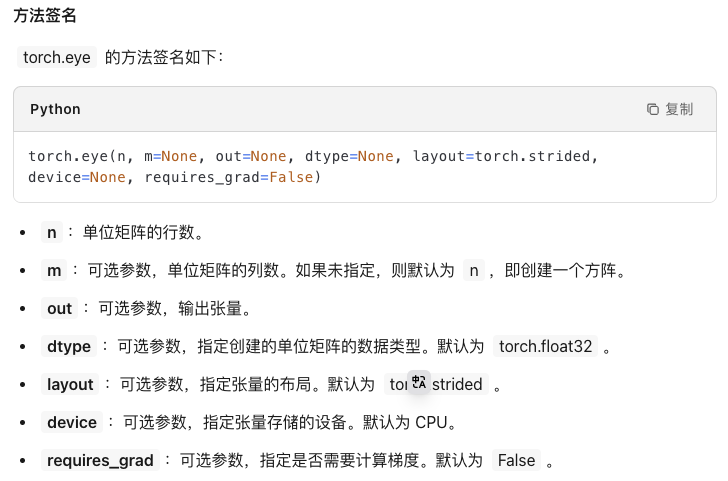

In [19]:
Image(filename='./Image/torch.eye.png',width=600)

In [20]:
import torch

# 创建一个 3x3 的单位矩阵
identity_matrix = torch.eye(3)
print(identity_matrix)
# 输出:
# tensor([[1., 0., 0.],
#         [0., 1., 0.],
#         [0., 0., 1.]])

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


In [21]:
# 创建一个 3x4 的单位矩阵
identity_matrix = torch.eye(3, 4)
print(identity_matrix)
# 输出:
# tensor([[1., 0., 0., 0.],
#         [0., 1., 0., 0.],
#         [0., 0., 1., 0.]])

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.]])


In [22]:
# 创建一个 3x3 的单位矩阵，指定数据类型为 torch.int64 和设备为 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
identity_matrix = torch.eye(3, dtype=torch.int64, device=device)
print(identity_matrix)
# 输出:
# tensor([[1, 0, 0],
#         [0, 1, 0],
#         [0, 0, 1]], device='cuda:0')

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]])


In [23]:
# 创建一个 3x3 的单位矩阵，指定 requires_grad=True
identity_matrix = torch.eye(3, requires_grad=True)
print(identity_matrix)
# 输出:
# tensor([[1., 0., 0.],
#         [0., 1., 0.],
#         [0., 0., 1.]], requires_grad=True)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]], requires_grad=True)


#### torch.empty 和 torch.empty_like

torch.empty 和 torch.empty_like 是 PyTorch 中用于创建未初始化张量的方法。
- 这些方法创建的张量不包含任何特定的值，其内容是随机的，取决于内存中的当前值。
- 这些方法在某些情况下非常有用，例如在需要分配内存但不立即初始化数据时。

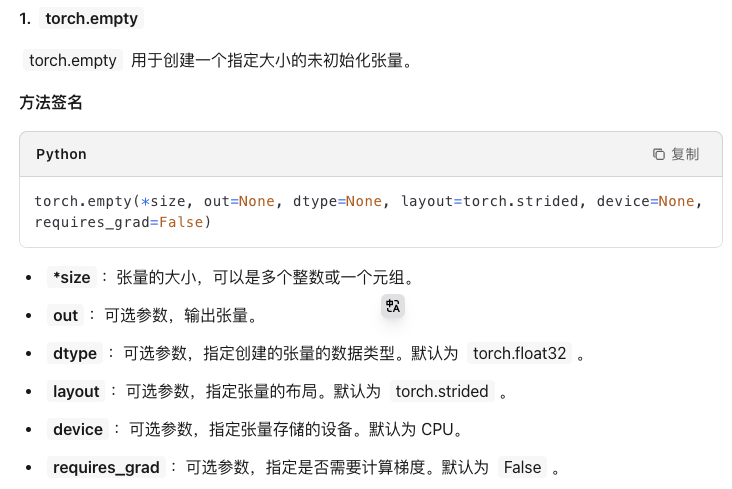

In [24]:
Image(filename='./Image/torch.empty.png',width=600)

In [25]:
import torch

# 创建一个 2x3 的未初始化张量
x = torch.empty(2, 3)
print(x)
# 输出: tensor([[1.2345e-38, 1.2345e-38, 1.2345e-38],
#               [1.2345e-38, 1.2345e-38, 1.2345e-38]])

# 创建一个 2x3 的未初始化张量，指定数据类型为 torch.int64
x = torch.empty(2, 3, dtype=torch.int64)
print(x)
# 输出: tensor([[4607182418800017408, 4607182418800017408, 4607182418800017408],
#               [4607182418800017408, 4607182418800017408, 4607182418800017408]])

# 创建一个 2x3 的未初始化张量，指定设备为 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.empty(2, 3, device=device)
print(x)
# 输出: tensor([[1.2345e-38, 1.2345e-38, 1.2345e-38],
#               [1.2345e-38, 1.2345e-38, 1.2345e-38]], device='cuda:0')

tensor([[0.0000e+00, 1.5846e+29, 7.0417e-25],
        [2.0005e+00, 8.4078e-45, 0.0000e+00]])
tensor([[         1065353223,                   0, 4575657221408423936],
        [                  0,                   0,          1065353216]])
tensor([[8.4078e-45, 1.8750e+00, 0.0000e+00],
        [1.8750e+00, 0.0000e+00, 1.8750e+00]])


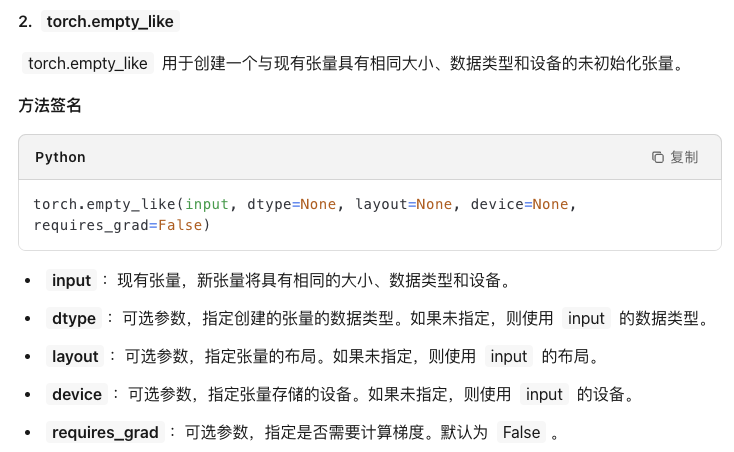

In [26]:
Image(filename='./Image/torch.empty_like.png',width=600)

In [28]:
import torch

# 创建一个现有的张量
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32, device='cpu')

# 创建一个与 x 具有相同大小、数据类型和设备的未初始化张量
y = torch.empty_like(x)
print(y)
# 输出: tensor([[1.2345e-38, 1.2345e-38],
#               [1.2345e-38, 1.2345e-38]], device='cuda:0')

# 创建一个与 x 具有相同大小，但数据类型为 torch.int64 的未初始化张量
y = torch.empty_like(x, dtype=torch.int64)
print(y)
# 输出: tensor([[4607182418800017408, 4607182418800017408],
#               [4607182418800017408, 4607182418800017408]], device='cuda:0')

tensor([[0.0000e+00, 1.8750e+00],
        [5.2362e-34, 1.4013e-45]])
tensor([[3947405073390239750, 4611123068473966592],
        [4611123068473966592, 4611123068473966592]])


### torch.arange

在 PyTorch 中，torch.arange 是一个用于创建一维张量的函数，该张量包含从指定的起始值到结束值的连续整数。
- 这个函数类似于 NumPy 中的 np.arange，非常适用于生成序列数据。

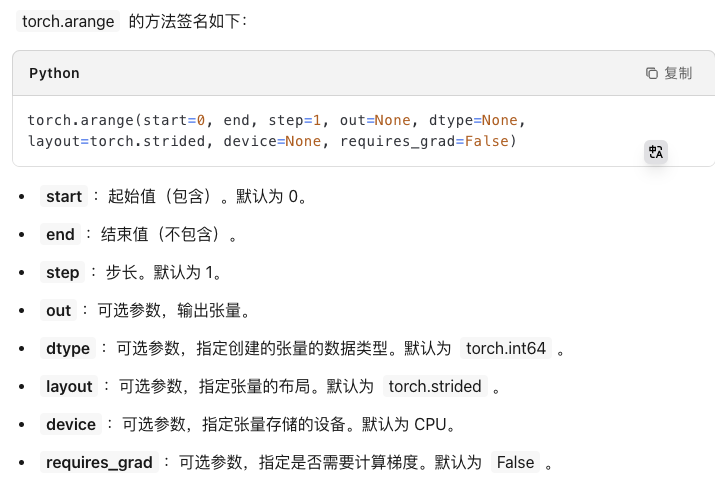

In [29]:
Image(filename='./Image/torch.arange.png',width=600)

注意事项
- 结束值不包含：
  - torch.arange 的结束值是不包含的，即生成的张量不会包含 end 值。
- 步长：
  - 步长可以是正数或负数。如果步长为负数，起始值必须大于结束值。
- 数据类型：
  - 默认情况下，torch.arange 创建的张量的数据类型是 torch.int64。如果需要其他数据类型，可以通过 dtype 参数指定。
- 设备：
  - 默认情况下，torch.arange 创建的张量存储在 CPU 上。如果需要将张量存储在 GPU 上，可以通过 device 参数指定。
- 梯度计算：
  - 如果需要在反向传播中使用这个张量，可以设置 requires_grad=True。

In [30]:
import torch

# 创建一个从 0 到 5 的张量
x = torch.arange(5)
print(x)
# 输出: tensor([0, 1, 2, 3, 4])

tensor([0, 1, 2, 3, 4])


In [31]:
# 创建一个从 1 到 5 的张量
x = torch.arange(1, 6)
print(x)
# 输出: tensor([1, 2, 3, 4, 5])

tensor([1, 2, 3, 4, 5])


In [32]:
# 创建一个从 0 到 10，步长为 2 的张量
x = torch.arange(0, 10, 2)
print(x)
# 输出: tensor([0, 2, 4, 6, 8])

tensor([0, 2, 4, 6, 8])


In [37]:
# 创建一个从 0 到 10，步长为 -2 的张量
x = torch.arange(10, 0, -2)
print(x)
# 输出: tensor([0, 2, 4, 6, 8])

tensor([10,  8,  6,  4,  2])


In [33]:
# 创建一个从 0 到 5 的张量，指定数据类型为 torch.float32 和设备为 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.arange(5, dtype=torch.float32, device=device)
print(x)
# 输出: tensor([0., 1., 2., 3., 4.], device='cuda:0')

tensor([0., 1., 2., 3., 4.])


In [35]:
# 创建一个从 0 到 5 的张量，指定 requires_grad=True
x = torch.arange(5, dtype=torch.float32,requires_grad=True)
print(x)
# 输出: tensor([0, 1, 2, 3, 4], requires_grad=True)

tensor([0., 1., 2., 3., 4.], requires_grad=True)


### torch.linspace
torch.linspace 是 PyTorch 中的一个函数，用于创建一个包含在指定区间内均匀分布的值的一维张量。
- 这个函数类似于 NumPy 中的 np.linspace，非常适用于生成等间隔的序列数据，
- 例如在插值、绘图或生成测试数据时。

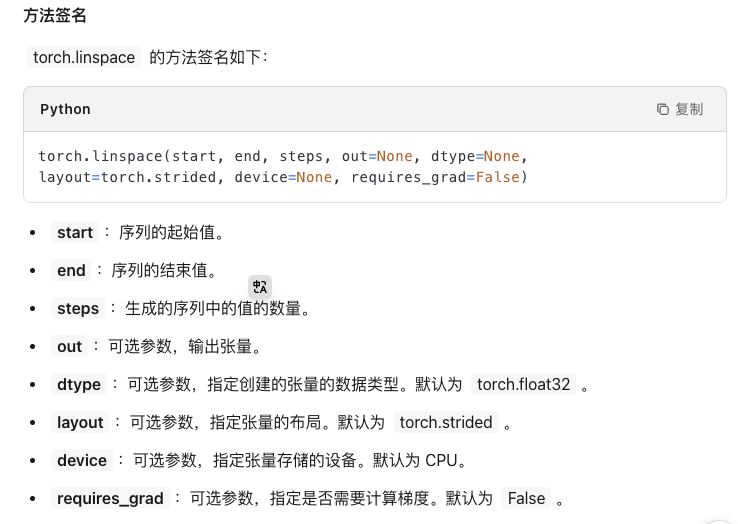

In [38]:
Image(filename='./Image/torch.linspace.png',width=600)

In [39]:
import torch

# 创建一个从 0 到 10 的等间隔序列，包含 5 个值
x = torch.linspace(0, 10, 5)
print(x)
# 输出: tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])

tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])


In [40]:
# 创建一个从 0 到 10 的等间隔序列，包含 5 个值，指定数据类型为 torch.float64 和设备为 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 10, 5, dtype=torch.float64, device=device)
print(x)
# 输出: tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000], device='cuda:0', dtype=torch.float64)

tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000], dtype=torch.float64)
